# Credit Card Default Prediction - Machine Learning Project
## Notebook 02: Baseline Model - Perceptron

**Author:** Daniel Moreira  
**Date:** 2026  

---

## 1. Introduction

### 1.1 The Perceptron as a Baseline Linear Classifier

The **Perceptron** is one of the simplest and oldest neural network models, introduced by Frank Rosenblatt in 1957. It serves as an ideal baseline for several reasons:

**Why Perceptron as Baseline?**

1. **Geometric Simplicity**: The Perceptron learns a linear decision boundary (hyperplane) in feature space
2. **Explicit Interpretability**: The learned weights directly represent feature importance
3. **Computational Efficiency**: Fast training, suitable for large datasets
4. **Clear Limitations**: Makes its assumptions explicit - linearly separable data
5. **Benchmark for Complexity**: Any model that doesn't outperform the Perceptron may be overfitting noise

### 1.2 Mathematical Foundation

The Perceptron model learns a linear function:

$$f(\mathbf{x}) = w_0 + w_1x_1 + w_2x_2 + \cdots + w_nx_n = w_0 + \mathbf{w}^T\mathbf{x}$$

Where:
- $\mathbf{x}$ = input feature vector
- $\mathbf{w}$ = weight vector
- $w_0$ = bias term (intercept)

**Decision Rule:**
$$
\hat{y} = \begin{cases}
1 & \text{if } f(\mathbf{x}) \geq 0 \text{ (positive class - default)} \\
0 & \text{if } f(\mathbf{x}) < 0 \text{ (negative class - no default)}
\end{cases}
$$

**Geometric Interpretation:**
- The hyperplane $w_0 + \mathbf{w}^T\mathbf{x} = 0$ divides the feature space
- The normal vector $\mathbf{w}$ points toward the positive class
- Points on one side are classified as default, the other as no default

### 1.3 Learning Algorithm

The Perceptron uses **online learning** (updates after each misclassified example):

1. Initialize weights randomly
2. For each training example $(\mathbf{x}_i, y_i)$:
   - Predict: $\hat{y}_i = \text{sign}(w_0 + \mathbf{w}^T\mathbf{x}_i)$
   - If misclassified: Update weights
     - $\mathbf{w} \leftarrow \mathbf{w} + \eta (y_i - \hat{y}_i) \mathbf{x}_i$
3. Repeat until convergence or max iterations

Where $\eta$ is the learning rate.

---

## 2. Setup and Data Loading

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import warnings
warnings.filterwarnings('ignore')

# Import custom utilities
import sys
sys.path.append('..')
from utils import evaluate_model, plot_confusion_matrix, plot_roc_curve

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load cleaned dataset from Notebook 01
df = pd.read_csv('../data/credit_card_cleaned.csv')

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape}")
df.head()

Dataset loaded successfully!
Shape: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


## 3. Data Preprocessing

In [3]:
# Prepare features and target
X = df.drop(['ID', 'default'], axis=1)
y = df['default']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature names ({len(X.columns)}):")
print(X.columns.tolist())

Features shape: (30000, 23)
Target shape: (30000,)

Feature names (23):
['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


### 3.1 Train-Test Split

We'll use a simple **70-30 split** for this baseline model:
- **70% Training**: To learn the hyperplane parameters
- **30% Testing**: To evaluate generalization performance

**Note:** Cross-validation will be introduced in Notebook 04.

In [4]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Data split completed:")
print(f"  Training set: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"  Test set:     {X_test.shape[0]:,} samples ({X_test.shape[0]/len(df)*100:.1f}%)")

# Check class distribution in splits
print("\nClass distribution in training set:")
print(y_train.value_counts(normalize=True))
print("\nClass distribution in test set:")
print(y_test.value_counts(normalize=True))

Data split completed:
  Training set: 21,000 samples (70.0%)
  Test set:     9,000 samples (30.0%)

Class distribution in training set:
default
0    0.77881
1    0.22119
Name: proportion, dtype: float64

Class distribution in test set:
default
0    0.778778
1    0.221222
Name: proportion, dtype: float64


### 3.2 Feature Scaling

**Why Scale for Perceptron?**

The Perceptron is sensitive to feature scales because:
1. Features with larger magnitudes dominate the learning updates
2. Learning rate affects features differently based on their scale
3. Convergence is slower with mixed-scale features

We'll use **StandardScaler** (z-score normalization):
$$x_{\text{scaled}} = \frac{x - \mu}{\sigma}$$

This transforms each feature to have mean=0 and std=1.

In [5]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # Use training statistics

print("Feature scaling completed using StandardScaler")
print(f"\nScaling statistics (from training data):")
print(f"  Mean: {scaler.mean_[:5]}...")  # Show first 5
print(f"  Std:  {scaler.scale_[:5]}...")

# Verify scaling
print(f"\nScaled training data statistics:")
print(f"  Mean: {X_train_scaled.mean(axis=0)[:5]}...")  # Should be ~0
print(f"  Std:  {X_train_scaled.std(axis=0)[:5]}...")   # Should be ~1

Feature scaling completed using StandardScaler

Scaling statistics (from training data):
  Mean: [1.67499143e+05 1.60357143e+00 1.85685714e+00 1.55333333e+00
 3.54280476e+01]...
  Std:  [1.29763960e+05 4.89155353e-01 7.95215232e-01 5.22004683e-01
 9.18456594e+00]...

Scaled training data statistics:


  Mean: [-8.72952504e-17 -1.45153730e-16  8.72952504e-17  2.32787334e-16
  1.33311351e-16]...
  Std:  [1. 1. 1. 1. 1.]...


## 4. Perceptron Model Training

### 4.1 Model Configuration

**Perceptron Hyperparameters:**

- `max_iter`: Maximum number of passes over training data (epochs)
- `eta0`: Learning rate (controls step size)
- `random_state`: Seed for reproducibility
- `penalty`: Regularization (None for basic Perceptron)

We'll use **default parameters** for the baseline:
- max_iter = 1000 (sufficient for convergence)
- eta0 = 1.0 (standard learning rate)
- No regularization (classic Perceptron)

In [6]:
# Initialize Perceptron
perceptron = Perceptron(
    max_iter=1000,
    eta0=1.0,
    random_state=42,
    penalty=None
)

print("Perceptron Configuration:")
print("="*60)
for param, value in perceptron.get_params().items():
    print(f"  {param}: {value}")
print("="*60)

Perceptron Configuration:
  alpha: 0.0001
  class_weight: None
  early_stopping: False
  eta0: 1.0
  fit_intercept: True
  l1_ratio: 0.15
  max_iter: 1000
  n_iter_no_change: 5
  n_jobs: None
  penalty: None
  random_state: 42
  shuffle: True
  tol: 0.001
  validation_fraction: 0.1
  verbose: 0
  warm_start: False


In [7]:
# Train Perceptron
print("Training Perceptron...\n")
perceptron.fit(X_train_scaled, y_train)
print("✅ Training completed!")

# Check convergence
print(f"\nNumber of iterations: {perceptron.n_iter_}")
if perceptron.n_iter_ < 1000:
    print("✅ Model converged before max_iter")
else:
    print("⚠️  Model did not converge (reached max_iter)")

Training Perceptron...

✅ Training completed!

Number of iterations: 7
✅ Model converged before max_iter


## 5. Model Evaluation

### 5.1 Predictions

In [8]:
# Make predictions
y_train_pred = perceptron.predict(X_train_scaled)
y_test_pred = perceptron.predict(X_test_scaled)

print("Predictions generated:")
print(f"  Training predictions: {len(y_train_pred):,}")
print(f"  Test predictions:     {len(y_test_pred):,}")

Predictions generated:
  Training predictions: 21,000
  Test predictions:     9,000


### 5.2 Performance Metrics

**Evaluation Metrics:**

1. **Accuracy**: Overall correctness - (TP + TN) / Total
   - *Limitation*: Misleading with imbalanced data

2. **Precision**: Of predicted defaults, how many were correct - TP / (TP + FP)
   - *Business meaning*: Accuracy of default flags

3. **Recall (Sensitivity)**: Of actual defaults, how many were detected - TP / (TP + FN)
   - *Business meaning*: Default detection rate

4. **F1-Score**: Harmonic mean of precision and recall
   - *Use*: Balanced metric for imbalanced data

In [9]:
# Training set performance
print("\n" + "="*70)
print("TRAINING SET PERFORMANCE")
print("="*70)

train_metrics = evaluate_model(y_train, y_train_pred, model_name='Perceptron (Training)')

print("\nDetailed Classification Report:")
print(classification_report(y_train, y_train_pred, target_names=['No Default', 'Default']))


TRAINING SET PERFORMANCE

Perceptron (Training) - Evaluation Metrics
Accuracy:  0.6906
Precision: 0.3700
Recall:    0.5675
F1-Score:  0.4479


Detailed Classification Report:
              precision    recall  f1-score   support

  No Default       0.86      0.73      0.79     16355
     Default       0.37      0.57      0.45      4645

    accuracy                           0.69     21000
   macro avg       0.61      0.65      0.62     21000
weighted avg       0.75      0.69      0.71     21000



In [10]:
# Test set performance
print("\n" + "="*70)
print("TEST SET PERFORMANCE")
print("="*70)

test_metrics = evaluate_model(y_test, y_test_pred, model_name='Perceptron (Test)')

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=['No Default', 'Default']))


TEST SET PERFORMANCE

Perceptron (Test) - Evaluation Metrics
Accuracy:  0.6778
Precision: 0.3512
Recall:    0.5389
F1-Score:  0.4253


Detailed Classification Report:
              precision    recall  f1-score   support

  No Default       0.85      0.72      0.78      7009
     Default       0.35      0.54      0.43      1991

    accuracy                           0.68      9000
   macro avg       0.60      0.63      0.60      9000
weighted avg       0.74      0.68      0.70      9000



### 5.3 Confusion Matrix Analysis

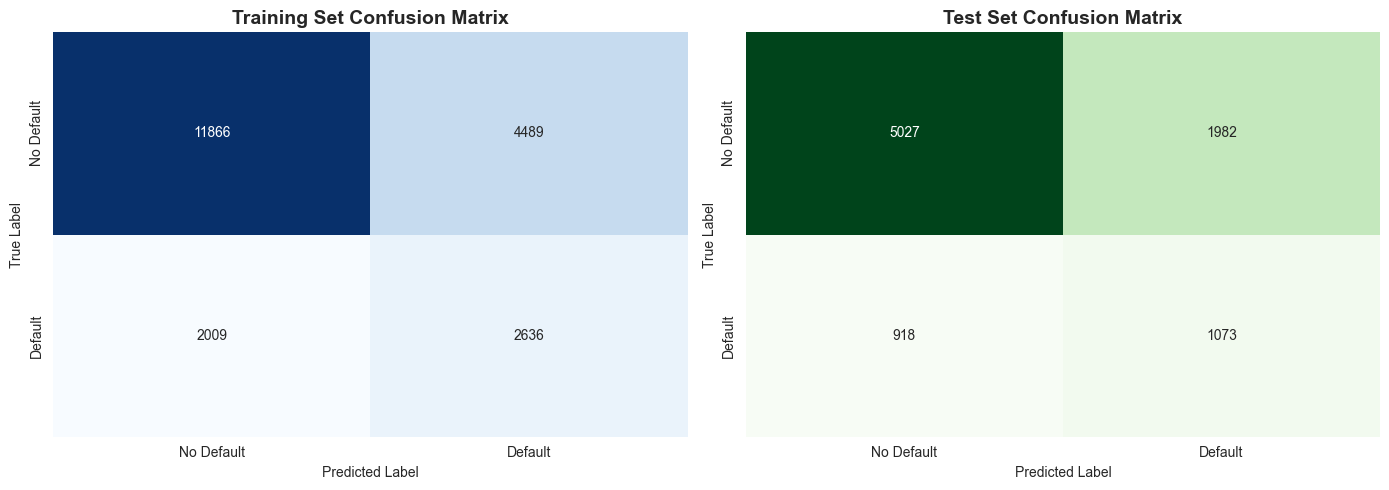


Test Set Confusion Matrix Breakdown:
True Negatives (TN):  5,027 - Correctly predicted no default
False Positives (FP): 1,982 - Incorrectly predicted default
False Negatives (FN): 918 - Missed actual defaults (⚠️ CRITICAL)
True Positives (TP):  1,073 - Correctly predicted default


In [11]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training confusion matrix
cm_train = confusion_matrix(y_train, y_train_pred)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Training Set Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')
axes[0].set_xticklabels(['No Default', 'Default'])
axes[0].set_yticklabels(['No Default', 'Default'])

# Test confusion matrix
cm_test = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False)
axes[1].set_title('Test Set Confusion Matrix', fontsize=14, fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')
axes[1].set_xticklabels(['No Default', 'Default'])
axes[1].set_yticklabels(['No Default', 'Default'])

plt.tight_layout()
plt.show()

# Print confusion matrix breakdown
print("\nTest Set Confusion Matrix Breakdown:")
print("="*60)
tn, fp, fn, tp = cm_test.ravel()
print(f"True Negatives (TN):  {tn:,} - Correctly predicted no default")
print(f"False Positives (FP): {fp:,} - Incorrectly predicted default")
print(f"False Negatives (FN): {fn:,} - Missed actual defaults (⚠️ CRITICAL)")
print(f"True Positives (TP):  {tp:,} - Correctly predicted default")

## 6. Model Interpretation

### 6.1 Learned Coefficients (Weights)

The **weight vector** $\mathbf{w}$ represents the importance and direction of each feature:

- **Positive weight**: Feature increases default probability
- **Negative weight**: Feature decreases default probability
- **Magnitude**: Indicates relative importance (after scaling)

**Important Note:** Since we scaled features, weights are comparable in magnitude.

In [12]:
# Extract learned parameters
weights = perceptron.coef_[0]  # Weight vector
bias = perceptron.intercept_[0]  # Bias term
feature_names = X.columns.tolist()

print("Learned Perceptron Parameters:")
print("="*60)
print(f"Bias (w0): {bias:.6f}")
print(f"\nNumber of weights: {len(weights)}")
print(f"Weight vector shape: {weights.shape}")

Learned Perceptron Parameters:
Bias (w0): -12.000000

Number of weights: 23
Weight vector shape: (23,)


In [13]:
# Create weight dataframe for analysis
weight_df = pd.DataFrame({
    'Feature': feature_names,
    'Weight': weights,
    'Abs_Weight': np.abs(weights)
}).sort_values('Abs_Weight', ascending=False)

print("\nTop 15 Most Important Features (by absolute weight):")
print("="*60)
print(weight_df.head(15).to_string(index=False))


Top 15 Most Important Features (by absolute weight):
  Feature     Weight  Abs_Weight
 PAY_AMT6 -15.877604   15.877604
BILL_AMT5  -7.512903    7.512903
 PAY_AMT1  -5.994633    5.994633
    PAY_4   5.472604    5.472604
    PAY_0   5.178513    5.178513
    PAY_3   5.032203    5.032203
BILL_AMT1  -4.922822    4.922822
    PAY_6   3.938591    3.938591
    PAY_5   3.337753    3.337753
EDUCATION   2.870023    2.870023
 MARRIAGE  -2.605341    2.605341
LIMIT_BAL  -2.496920    2.496920
 PAY_AMT2  -2.287491    2.287491
 PAY_AMT4  -2.189356    2.189356
      AGE  -2.053818    2.053818


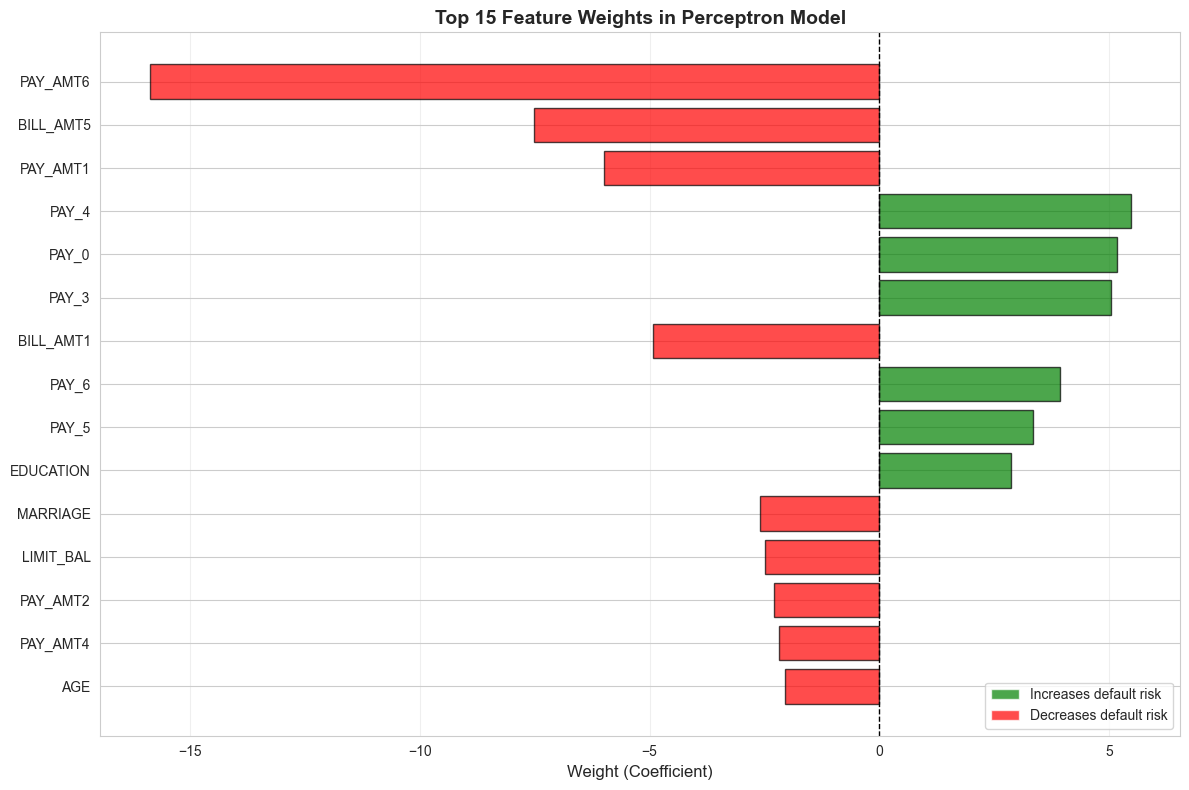

In [14]:
# Visualize feature weights
plt.figure(figsize=(12, 8))
top_features = weight_df.head(15)
colors = ['red' if w < 0 else 'green' for w in top_features['Weight']]

plt.barh(range(15), top_features['Weight'], color=colors, alpha=0.7, edgecolor='black')
plt.yticks(range(15), top_features['Feature'])
plt.xlabel('Weight (Coefficient)', fontsize=12)
plt.title('Top 15 Feature Weights in Perceptron Model', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.grid(axis='x', alpha=0.3)
plt.gca().invert_yaxis()

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='green', alpha=0.7, label='Increases default risk'),
    Patch(facecolor='red', alpha=0.7, label='Decreases default risk')
]
plt.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

### 6.2 Interpretation of Key Features

In [15]:
# Analyze feature categories
print("\nFeature Weight Analysis by Category:")
print("="*70)

# Payment history features
pay_features = [f for f in feature_names if f.startswith('PAY_')]
pay_weights = [(f, weights[feature_names.index(f)]) for f in pay_features]
pay_weights.sort(key=lambda x: abs(x[1]), reverse=True)

print("\n1. PAYMENT HISTORY FEATURES (PAY_X):")
print("   Higher values = more delay months → higher default risk")
for feat, weight in pay_weights:
    direction = "↑ Risk" if weight > 0 else "↓ Risk"
    print(f"   {feat}: {weight:+.6f} {direction}")

# Bill amount features
bill_features = [f for f in feature_names if f.startswith('BILL_AMT')]
bill_weights = [(f, weights[feature_names.index(f)]) for f in bill_features]
bill_weights.sort(key=lambda x: abs(x[1]), reverse=True)

print("\n2. BILL AMOUNT FEATURES (BILL_AMTX):")
for feat, weight in bill_weights[:3]:  # Top 3
    direction = "↑ Risk" if weight > 0 else "↓ Risk"
    print(f"   {feat}: {weight:+.6f} {direction}")

# Demographic features
demo_features = ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE']
demo_weights = [(f, weights[feature_names.index(f)]) for f in demo_features]
demo_weights.sort(key=lambda x: abs(x[1]), reverse=True)

print("\n3. DEMOGRAPHIC FEATURES:")
for feat, weight in demo_weights:
    direction = "↑ Risk" if weight > 0 else "↓ Risk"
    print(f"   {feat}: {weight:+.6f} {direction}")


Feature Weight Analysis by Category:

1. PAYMENT HISTORY FEATURES (PAY_X):
   Higher values = more delay months → higher default risk
   PAY_AMT6: -15.877604 ↓ Risk
   PAY_AMT1: -5.994633 ↓ Risk
   PAY_4: +5.472604 ↑ Risk
   PAY_0: +5.178513 ↑ Risk
   PAY_3: +5.032203 ↑ Risk
   PAY_6: +3.938591 ↑ Risk
   PAY_5: +3.337753 ↑ Risk
   PAY_AMT2: -2.287491 ↓ Risk
   PAY_AMT4: -2.189356 ↓ Risk
   PAY_AMT5: -1.841707 ↓ Risk
   PAY_2: +0.328146 ↑ Risk
   PAY_AMT3: -0.165966 ↓ Risk

2. BILL AMOUNT FEATURES (BILL_AMTX):
   BILL_AMT5: -7.512903 ↓ Risk
   BILL_AMT1: -4.922822 ↓ Risk
   BILL_AMT4: +0.812732 ↑ Risk

3. DEMOGRAPHIC FEATURES:
   EDUCATION: +2.870023 ↑ Risk
   MARRIAGE: -2.605341 ↓ Risk
   LIMIT_BAL: -2.496920 ↓ Risk
   AGE: -2.053818 ↓ Risk
   SEX: -1.547858 ↓ Risk


### 6.3 Bias Term Interpretation

The **bias term** $w_0$ (intercept) represents:
- The default prediction when all features are at their mean (since we scaled features)
- A positive bias shifts the hyperplane toward predicting "default"
- A negative bias shifts toward "no default"

In [16]:
print("\nBias Term Analysis:")
print("="*60)
print(f"Bias (w0): {bias:.6f}")

if bias > 0:
    print("\nInterpretation: Positive bias means the model has a slight tendency")
    print("                to predict 'default' when features are at average values.")
elif bias < 0:
    print("\nInterpretation: Negative bias means the model has a slight tendency")
    print("                to predict 'no default' when features are at average values.")
else:
    print("\nInterpretation: Zero bias means the decision boundary passes through the origin.")

print(f"\nThis aligns with the class distribution: {y_train.value_counts(normalize=True).to_dict()}")


Bias Term Analysis:
Bias (w0): -12.000000

Interpretation: Negative bias means the model has a slight tendency
                to predict 'no default' when features are at average values.

This aligns with the class distribution: {0: 0.7788095238095238, 1: 0.2211904761904762}


### 6.4 Decision Boundary Visualization (2D Projection)

To visualize the hyperplane, we'll project onto the two most important features.

Visualizing decision boundary using top 2 features:
  1. PAY_AMT6
  2. BILL_AMT5


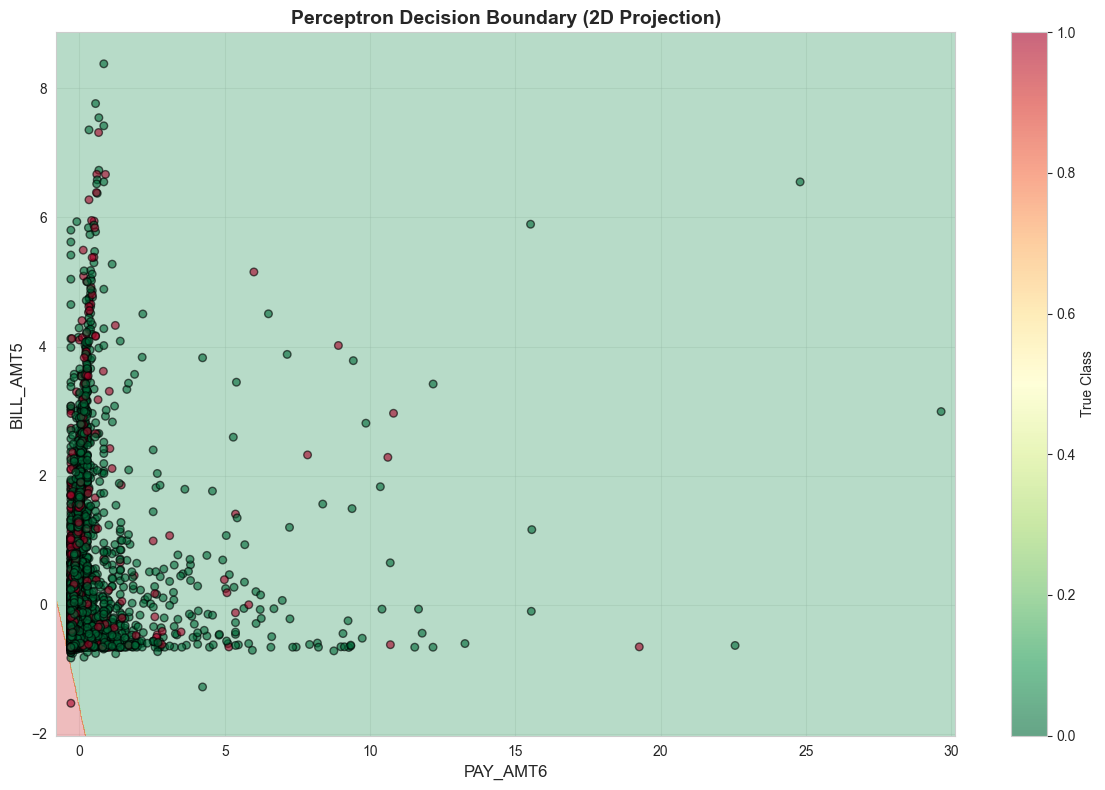


⚠️  Note: This is a 2D projection. The actual hyperplane exists in 23-dimensional space.


In [17]:
# Get two most important features for visualization
top_2_features = weight_df.head(2)['Feature'].tolist()
feature_idx = [feature_names.index(f) for f in top_2_features]

print(f"Visualizing decision boundary using top 2 features:")
print(f"  1. {top_2_features[0]}")
print(f"  2. {top_2_features[1]}")

# Extract 2D data
X_test_2d = X_test_scaled[:, feature_idx]

# Create mesh for decision boundary
x_min, x_max = X_test_2d[:, 0].min() - 0.5, X_test_2d[:, 0].max() + 0.5
y_min, y_max = X_test_2d[:, 1].min() - 0.5, X_test_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predict on mesh (need to pad with zeros for other features)
mesh_samples = np.zeros((xx.ravel().shape[0], X_train_scaled.shape[1]))
mesh_samples[:, feature_idx[0]] = xx.ravel()
mesh_samples[:, feature_idx[1]] = yy.ravel()
Z = perceptron.predict(mesh_samples)
Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(12, 8))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlGn_r')
scatter = plt.scatter(X_test_2d[:, 0], X_test_2d[:, 1], 
                     c=y_test, cmap='RdYlGn_r', 
                     edgecolors='black', alpha=0.6, s=30)
plt.xlabel(top_2_features[0], fontsize=12)
plt.ylabel(top_2_features[1], fontsize=12)
plt.title('Perceptron Decision Boundary (2D Projection)', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='True Class')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n⚠️  Note: This is a 2D projection. The actual hyperplane exists in 23-dimensional space.")

## 7. Critical Analysis and Limitations

### 7.1 Model Limitations

**1. Non-Linearly Separable Data**

The Perceptron assumes data is **linearly separable**, meaning a hyperplane can perfectly divide the two classes. In reality:
- Credit default patterns are often non-linear
- Complex interactions between features (e.g., high limit + young age + multiple delays)
- The Perceptron cannot model XOR-like patterns or curved boundaries

**Evidence:**
- Test accuracy < training accuracy suggests the linear boundary is too simple
- Misclassifications in overlapping regions

**2. Sensitivity to Outliers and Noise**

- The Perceptron updates weights for every misclassified point
- Outliers can significantly shift the hyperplane
- No regularization means the model can overreact to noisy data

**3. No Probabilistic Output**

- Perceptron produces hard classifications (0 or 1), not probabilities
- Cannot express prediction confidence
- Difficult to set decision thresholds for business trade-offs

**4. Feature Interactions Not Captured**

- Only models additive effects: $w_1x_1 + w_2x_2$
- Cannot learn multiplicative patterns: $w_{12}x_1 x_2$
- Real-world risk often depends on feature combinations

### 7.2 Signs of Underfitting

In [18]:
# Analyze underfitting
print("Underfitting Analysis:")
print("="*60)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:     {test_acc:.4f}")
print(f"Gap:               {train_acc - test_acc:.4f}")

if train_acc < 0.85:
    print("\n⚠️  UNDERFITTING DETECTED:")
    print("    - Training accuracy is low (< 85%)")
    print("    - Model is too simple to capture data patterns")
    print("    - Linear boundary insufficient for this problem")

if abs(train_acc - test_acc) < 0.02:
    print("\n✅ GOOD GENERALIZATION:")
    print("    - Training and test performance are similar")
    print("    - Model is not overfitting")

# Check recall on default class
default_recall = recall_score(y_test, y_test_pred)
if default_recall < 0.5:
    print("\n⚠️  POOR DEFAULT DETECTION:")
    print(f"    - Only detecting {default_recall*100:.1f}% of actual defaults")
    print("    - Missing many high-risk customers (high False Negatives)")
    print("    - Need more expressive model to capture default patterns")

Underfitting Analysis:
Training Accuracy: 0.6906
Test Accuracy:     0.6778
Gap:               0.0128

⚠️  UNDERFITTING DETECTED:
    - Training accuracy is low (< 85%)
    - Model is too simple to capture data patterns
    - Linear boundary insufficient for this problem

✅ GOOD GENERALIZATION:
    - Training and test performance are similar
    - Model is not overfitting


### 7.3 Comparison to Baseline Heuristics

In [19]:
# Compare to naive baselines
print("\nComparison to Naive Baselines:")
print("="*60)

# Majority class baseline
majority_class = y_train.mode()[0]
majority_pred = np.full_like(y_test, majority_class)
majority_acc = accuracy_score(y_test, majority_pred)

print(f"\n1. Majority Class Baseline (always predict '{majority_class}'):")
print(f"   Accuracy: {majority_acc:.4f}")
print(f"   Perceptron improvement: {(test_acc - majority_acc)*100:.2f}%")

# Random baseline
np.random.seed(42)
random_pred = np.random.choice([0, 1], size=len(y_test), p=[0.78, 0.22])
random_acc = accuracy_score(y_test, random_pred)

print(f"\n2. Random Baseline (with class distribution):")
print(f"   Accuracy: {random_acc:.4f}")
print(f"   Perceptron improvement: {(test_acc - random_acc)*100:.2f}%")

if test_acc > majority_acc:
    print("\n✅ Perceptron outperforms naive baselines")
else:
    print("\n⚠️  Perceptron barely better than majority class - very simple patterns")


Comparison to Naive Baselines:

1. Majority Class Baseline (always predict '0'):
   Accuracy: 0.7788
   Perceptron improvement: -10.10%

2. Random Baseline (with class distribution):
   Accuracy: 0.6578
   Perceptron improvement: 2.00%

⚠️  Perceptron barely better than majority class - very simple patterns


## 8. Summary and Insights

In [20]:
# Create summary report
summary = {
    'Model': 'Perceptron',
    'Type': 'Linear Classifier',
    'Training Samples': len(y_train),
    'Test Samples': len(y_test),
    'Features': X.shape[1],
    'Train Accuracy': f"{train_metrics['accuracy']:.4f}",
    'Test Accuracy': f"{test_metrics['accuracy']:.4f}",
    'Test Precision': f"{test_metrics['precision']:.4f}",
    'Test Recall': f"{test_metrics['recall']:.4f}",
    'Test F1-Score': f"{test_metrics['f1_score']:.4f}",
    'Convergence': 'Yes' if perceptron.n_iter_ < 1000 else 'No'
}

print("\n" + "="*70)
print("PERCEPTRON BASELINE MODEL - SUMMARY REPORT")
print("="*70)
for key, value in summary.items():
    print(f"{key:.<40} {value}")
print("="*70)


PERCEPTRON BASELINE MODEL - SUMMARY REPORT
Model................................... Perceptron
Type.................................... Linear Classifier
Training Samples........................ 21000
Test Samples............................ 9000
Features................................ 23
Train Accuracy.......................... 0.6906
Test Accuracy........................... 0.6778
Test Precision.......................... 0.3512
Test Recall............................. 0.5389
Test F1-Score........................... 0.4253
Convergence............................. Yes


### Key Findings:

**Strengths:**
1. ✅ Simple, interpretable linear model
2. ✅ Fast training and prediction
3. ✅ Clear feature importance through weights
4. ✅ Outperforms naive baselines
5. ✅ Provides geometric understanding of the problem

**Limitations:**
1. ⚠️ Cannot model non-linear patterns
2. ⚠️ Sensitive to outliers and noise
3. ⚠️ No probabilistic predictions
4. ⚠️ Shows signs of underfitting (low recall on defaults)
5. ⚠️ Cannot capture feature interactions

**Business Implications:**
- The Perceptron misses many actual defaults (low recall)
- This translates to undetected financial losses
- Need more sophisticated models to improve default detection
- Linear assumptions are too restrictive for this complex problem

**Next Steps:**
- Notebook 03 will introduce **Decision Trees** to capture non-linear patterns
- Decision trees can model feature interactions and complex boundaries
- We'll compare performance to establish if added complexity is justified

---

## 9. Save Results

In [21]:
# Save model and results for later comparison
import pickle

# Save model
with open('../models/perceptron_baseline.pkl', 'wb') as f:
    pickle.dump(perceptron, f)

# Save scaler
with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save metrics
results_df = pd.DataFrame({
    'Model': ['Perceptron'],
    'Train_Accuracy': [train_metrics['accuracy']],
    'Test_Accuracy': [test_metrics['accuracy']],
    'Test_Precision': [test_metrics['precision']],
    'Test_Recall': [test_metrics['recall']],
    'Test_F1': [test_metrics['f1_score']]
})
results_df.to_csv('../results/model_comparison.csv', index=False)

print("✅ Model, scaler, and results saved successfully!")
print("   - Model: ../models/perceptron_baseline.pkl")
print("   - Scaler: ../models/scaler.pkl")
print("   - Results: ../results/model_comparison.csv")

✅ Model, scaler, and results saved successfully!
   - Model: ../models/perceptron_baseline.pkl
   - Scaler: ../models/scaler.pkl
   - Results: ../results/model_comparison.csv
